#Baseline for Records

In [1]:
import sys
from pathlib import Path
import json
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.train_temporal import CV_SUMMARY_PATH, CV_CONFUSION_MATRIX_PATH

In [2]:
baseline_summary = pd.read_csv(CV_SUMMARY_PATH)
baseline_summary

,metric,mean,std
0,val_loss,0.740650,0.140909
1,accuracy,0.500000,0.235702
2,precision,0.570000,0.297303
3,recall,0.533333,0.298142
4,f1,0.507143,0.202311


In [3]:
baseline_confusion_matrix = np.load(CV_CONFUSION_MATRIX_PATH)
baseline_confusion_matrix

array([[7, 8],
       [7, 8]])

In [4]:
baseline_config = {
    "model_type": "GRU",
    "input_dim": 132,
    "hidden_dim": 64,
    "num_layers": 1,
    "num_classes": 2,
    "learning_rate": 1e-3,
    "epochs_cv": 5,
    "batch_size": 4,
    "evaluation": "clip-level stratified 5-fold cross-validation",
    "sequence_length": 30,
}

baseline_config

{'model_type': 'GRU',
 'input_dim': 132,
 'hidden_dim': 64,
 'num_layers': 1,
 'num_classes': 2,
 'learning_rate': 0.001,
 'epochs_cv': 5,
 'batch_size': 4,
 'evaluation': 'clip-level stratified 5-fold cross-validation',
 'sequence_length': 30}

In [5]:
baseline_dir = PROJECT_ROOT / "results" / "deliverable3_baseline"
baseline_dir.mkdir(parents=True, exist_ok=True)

baseline_dir

PosixPath('/Users/arjunrammohandas/Desktop/JumpSafe_Continuation/results/deliverable3_baseline')

In [6]:
baseline_summary_path = baseline_dir / "gru_d2_summary.csv"
baseline_cm_path = baseline_dir / "gru_d2_confusion_matrix.npy"
baseline_config_path = baseline_dir / "gru_d2_config.json"

baseline_summary.to_csv(baseline_summary_path, index=False)
np.save(baseline_cm_path, baseline_confusion_matrix)

with open(baseline_config_path, "w") as f:
    json.dump(baseline_config, f, indent=2)

print("Saved baseline summary to:", baseline_summary_path)
print("Saved baseline confusion matrix to:", baseline_cm_path)
print("Saved baseline config to:", baseline_config_path)

Saved baseline summary to: /Users/arjunrammohandas/Desktop/JumpSafe_Continuation/results/deliverable3_baseline/gru_d2_summary.csv
Saved baseline confusion matrix to: /Users/arjunrammohandas/Desktop/JumpSafe_Continuation/results/deliverable3_baseline/gru_d2_confusion_matrix.npy
Saved baseline config to: /Users/arjunrammohandas/Desktop/JumpSafe_Continuation/results/deliverable3_baseline/gru_d2_config.json


In [7]:
print(baseline_summary_path.exists())
print(baseline_cm_path.exists())
print(baseline_config_path.exists())

True
True
True


## GRU Refinement Experiments

This section tests a small set of GRU hyperparameter changes relative to the Deliverable 2 baseline. The goal is to determine whether tuning hidden dimension, number of training epochs, or learning rate improves cross-validated performance or stability.

In [8]:
from src.dataset import load_processed_metadata
from src.train_temporal import run_stratified_kfold_cv

In [9]:
#load processed metadata
processed_meta = load_processed_metadata()

print("Number of processed clips:", len(processed_meta))
processed_meta["label"].value_counts()

Number of processed clips: 30


label
bad_jump     15
good_jump    15
Name: count, dtype: int64

In [10]:
#define tuning grid
experiment_grid = [
    {"hidden_dim": 32,  "num_epochs": 10, "learning_rate": 1e-3},
    {"hidden_dim": 64,  "num_epochs": 10, "learning_rate": 1e-3},
    {"hidden_dim": 128, "num_epochs": 10, "learning_rate": 1e-3},
    {"hidden_dim": 32,  "num_epochs": 20, "learning_rate": 1e-3},
    {"hidden_dim": 64,  "num_epochs": 20, "learning_rate": 1e-3},
    {"hidden_dim": 128, "num_epochs": 20, "learning_rate": 1e-3},
    {"hidden_dim": 32,  "num_epochs": 10, "learning_rate": 5e-4},
    {"hidden_dim": 64,  "num_epochs": 10, "learning_rate": 5e-4},
    {"hidden_dim": 128, "num_epochs": 10, "learning_rate": 5e-4},
    {"hidden_dim": 32,  "num_epochs": 20, "learning_rate": 5e-4},
    {"hidden_dim": 64,  "num_epochs": 20, "learning_rate": 5e-4},
    {"hidden_dim": 128, "num_epochs": 20, "learning_rate": 5e-4},
]

len(experiment_grid)

12

In [11]:
#create results folder for tuning
tuning_dir = PROJECT_ROOT / "results" / "deliverable3_tuning"
tuning_dir.mkdir(parents=True, exist_ok=True)

tuning_dir

PosixPath('/Users/arjunrammohandas/Desktop/JumpSafe_Continuation/results/deliverable3_tuning')

In [12]:
#tuning loop
tuning_records = []

for i, config in enumerate(experiment_grid, start=1):
    print("=" * 70)
    print(f"Running experiment {i}/{len(experiment_grid)}")
    print(config)

    cv_outputs = run_stratified_kfold_cv(
        metadata_df=processed_meta,
        n_splits=5,
        num_epochs=config["num_epochs"],
        batch_size=4,
        learning_rate=config["learning_rate"],
        hidden_dim=config["hidden_dim"],
        save_results=False,
    )

    fold_results = cv_outputs["fold_results"]
    summary_df = cv_outputs["summary"]

    summary_map = dict(zip(summary_df["metric"], summary_df["mean"]))
    std_map = dict(zip(summary_df["metric"], summary_df["std"]))

    record = {
        "experiment_id": i,
        "model_type": "GRU",
        "hidden_dim": config["hidden_dim"],
        "num_epochs": config["num_epochs"],
        "learning_rate": config["learning_rate"],
        "accuracy_mean": summary_map.get("accuracy"),
        "accuracy_std": std_map.get("accuracy"),
        "precision_mean": summary_map.get("precision"),
        "precision_std": std_map.get("precision"),
        "recall_mean": summary_map.get("recall"),
        "recall_std": std_map.get("recall"),
        "f1_mean": summary_map.get("f1"),
        "f1_std": std_map.get("f1"),
        "val_loss_mean": summary_map.get("val_loss"),
        "val_loss_std": std_map.get("val_loss"),
    }

    tuning_records.append(record)

tuning_results_df = pd.DataFrame(tuning_records)
tuning_results_df

Running experiment 1/12
{'hidden_dim': 32, 'num_epochs': 10, 'learning_rate': 0.001}

Starting fold 1/5
Epoch 01 | Train Loss: 0.7449 | Train Acc: 0.5000 | Val Loss: 0.6745 | Val Acc: 0.5000
Epoch 02 | Train Loss: 0.6739 | Train Acc: 0.5833 | Val Loss: 0.6736 | Val Acc: 0.5000
Epoch 03 | Train Loss: 0.6657 | Train Acc: 0.5417 | Val Loss: 0.6793 | Val Acc: 0.6667
Epoch 04 | Train Loss: 0.6456 | Train Acc: 0.7500 | Val Loss: 0.6839 | Val Acc: 0.5000
Epoch 05 | Train Loss: 0.6290 | Train Acc: 0.7500 | Val Loss: 0.6846 | Val Acc: 0.5000
Epoch 06 | Train Loss: 0.6534 | Train Acc: 0.5417 | Val Loss: 0.6842 | Val Acc: 0.5000
Epoch 07 | Train Loss: 0.6076 | Train Acc: 0.6667 | Val Loss: 0.6958 | Val Acc: 0.5000
Epoch 08 | Train Loss: 0.5946 | Train Acc: 0.7917 | Val Loss: 0.7096 | Val Acc: 0.5000
Epoch 09 | Train Loss: 0.5868 | Train Acc: 0.7500 | Val Loss: 0.7028 | Val Acc: 0.5000
Epoch 10 | Train Loss: 0.5732 | Train Acc: 0.7500 | Val Loss: 0.7142 | Val Acc: 0.5000

Starting fold 2/5
Epoch 0

,experiment_id,model_type,hidden_dim,num_epochs,learning_rate,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,val_loss_mean,val_loss_std
0,1,GRU,32,10,0.0010,0.533333,0.247207,0.550000,0.370810,0.533333,0.380058,0.500000,0.311350,0.749065,0.182199
1,2,GRU,64,10,0.0010,0.466667,0.320590,0.450000,0.298142,0.533333,0.380058,0.485714,0.330601,0.762286,0.248466
2,3,GRU,128,10,0.0010,0.466667,0.320590,0.436667,0.287325,0.600000,0.434613,0.502381,0.343840,0.745588,0.243626
3,4,GRU,32,20,0.0010,0.633333,0.273861,0.540000,0.311047,0.800000,0.447214,0.642857,0.363339,0.771579,0.341088
4,5,GRU,64,20,0.0010,0.433333,0.278887,0.353333,0.327957,0.466667,0.447214,0.397619,0.368433,0.843449,0.545665
5,6,GRU,128,20,0.0010,0.500000,0.166667,0.420000,0.248998,0.666667,0.408248,0.514286,0.307848,0.844752,0.570704
6,7,GRU,32,10,0.0005,0.533333,0.247207,0.550000,0.370810,0.533333,0.380058,0.500000,0.311350,0.729779,0.112253
7,8,GRU,64,10,0.0005,0.500000,0.311805,0.483333,0.291071,0.600000,0.365148,0.533333,0.320147,0.735744,0.137145
8,9,GRU,128,10,0.0005,0.466667,0.320590,0.436667,0.287325,0.600000,0.434613,0.502381,0.343840,0.736048,0.192214
9,10,GRU,32,20,0.0005,0.533333,0.247207,0.483333,0.291071,0.600000,0.365148,0.533333,0.320147,0.739416,0.184913


In [13]:
#sort by best F1
tuning_results_sorted = tuning_results_df.sort_values(
    by=["f1_mean", "accuracy_mean"],
    ascending=[False, False]
).reset_index(drop=True)

tuning_results_sorted

,experiment_id,model_type,hidden_dim,num_epochs,learning_rate,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,val_loss_mean,val_loss_std
0,12,GRU,128,20,0.0005,0.633333,0.139443,0.590000,0.102470,0.933333,0.149071,0.719048,0.106679,0.743512,0.387041
1,4,GRU,32,20,0.0010,0.633333,0.273861,0.540000,0.311047,0.800000,0.447214,0.642857,0.363339,0.771579,0.341088
2,11,GRU,64,20,0.0005,0.500000,0.333333,0.456667,0.296179,0.666667,0.471405,0.538095,0.361619,0.754007,0.315901
3,10,GRU,32,20,0.0005,0.533333,0.247207,0.483333,0.291071,0.600000,0.365148,0.533333,0.320147,0.739416,0.184913
4,8,GRU,64,10,0.0005,0.500000,0.311805,0.483333,0.291071,0.600000,0.365148,0.533333,0.320147,0.735744,0.137145
5,6,GRU,128,20,0.0010,0.500000,0.166667,0.420000,0.248998,0.666667,0.408248,0.514286,0.307848,0.844752,0.570704
6,3,GRU,128,10,0.0010,0.466667,0.320590,0.436667,0.287325,0.600000,0.434613,0.502381,0.343840,0.745588,0.243626
7,9,GRU,128,10,0.0005,0.466667,0.320590,0.436667,0.287325,0.600000,0.434613,0.502381,0.343840,0.736048,0.192214
8,1,GRU,32,10,0.0010,0.533333,0.247207,0.550000,0.370810,0.533333,0.380058,0.500000,0.311350,0.749065,0.182199
9,7,GRU,32,10,0.0005,0.533333,0.247207,0.550000,0.370810,0.533333,0.380058,0.500000,0.311350,0.729779,0.112253


In [14]:
tuning_results_path = tuning_dir / "gru_tuning_results.csv"
tuning_results_sorted.to_csv(tuning_results_path, index=False)

print(tuning_results_path)
print(tuning_results_path.exists())

/Users/arjunrammohandas/Desktop/JumpSafe_Continuation/results/deliverable3_tuning/gru_tuning_results.csv
True


In [15]:
baseline_summary_map = dict(zip(baseline_summary["metric"], baseline_summary["mean"]))
baseline_std_map = dict(zip(baseline_summary["metric"], baseline_summary["std"]))

best_tuned = tuning_results_sorted.iloc[0]

comparison_df = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1", "val_loss"],
    "deliverable2_baseline": [
        f"{baseline_summary_map['accuracy']:.3f} ± {baseline_std_map['accuracy']:.3f}",
        f"{baseline_summary_map['precision']:.3f} ± {baseline_std_map['precision']:.3f}",
        f"{baseline_summary_map['recall']:.3f} ± {baseline_std_map['recall']:.3f}",
        f"{baseline_summary_map['f1']:.3f} ± {baseline_std_map['f1']:.3f}",
        f"{baseline_summary_map['val_loss']:.3f} ± {baseline_std_map['val_loss']:.3f}",
    ],
    "best_tuned_gru": [
        f"{best_tuned['accuracy_mean']:.3f} ± {best_tuned['accuracy_std']:.3f}",
        f"{best_tuned['precision_mean']:.3f} ± {best_tuned['precision_std']:.3f}",
        f"{best_tuned['recall_mean']:.3f} ± {best_tuned['recall_std']:.3f}",
        f"{best_tuned['f1_mean']:.3f} ± {best_tuned['f1_std']:.3f}",
        f"{best_tuned['val_loss_mean']:.3f} ± {best_tuned['val_loss_std']:.3f}",
    ]
})

comparison_df

,metric,deliverable2_baseline,best_tuned_gru
0,accuracy,0.500 ± 0.236,0.633 ± 0.139
1,precision,0.570 ± 0.297,0.590 ± 0.102
2,recall,0.533 ± 0.298,0.933 ± 0.149
3,f1,0.507 ± 0.202,0.719 ± 0.107
4,val_loss,0.741 ± 0.141,0.744 ± 0.387


In [16]:
best_tuned

experiment_id           12
model_type             GRU
hidden_dim             128
num_epochs              20
learning_rate       0.0005
accuracy_mean     0.633333
accuracy_std      0.139443
precision_mean        0.59
precision_std      0.10247
recall_mean       0.933333
recall_std        0.149071
f1_mean           0.719048
f1_std            0.106679
val_loss_mean     0.743512
val_loss_std      0.387041
Name: 0, dtype: object

In [17]:
best_row = tuning_results_sorted.iloc[0]

best_gru_config = {
    "model_type": "GRU",
    "hidden_dim": int(best_row["hidden_dim"]),
    "num_epochs": int(best_row["num_epochs"]),
    "learning_rate": float(best_row["learning_rate"]),
    "batch_size": 4,
    "n_splits": 5,
    "evaluation": "clip-level stratified 5-fold cross-validation",
}

best_gru_config

{'model_type': 'GRU',
 'hidden_dim': 128,
 'num_epochs': 20,
 'learning_rate': 0.0005,
 'batch_size': 4,
 'n_splits': 5,
 'evaluation': 'clip-level stratified 5-fold cross-validation'}

In [18]:
seeded_best_gru_outputs = run_stratified_kfold_cv(
    metadata_df=processed_meta,
    n_splits=best_gru_config["n_splits"],
    num_epochs=best_gru_config["num_epochs"],
    batch_size=best_gru_config["batch_size"],
    learning_rate=best_gru_config["learning_rate"],
    hidden_dim=best_gru_config["hidden_dim"],
    save_results=False,
)

seeded_best_gru_outputs["summary"]


Starting fold 1/5
Epoch 01 | Train Loss: 0.7674 | Train Acc: 0.5000 | Val Loss: 0.6801 | Val Acc: 0.5000
Epoch 02 | Train Loss: 0.6928 | Train Acc: 0.5000 | Val Loss: 0.6844 | Val Acc: 0.5000
Epoch 03 | Train Loss: 0.6896 | Train Acc: 0.5417 | Val Loss: 0.7059 | Val Acc: 0.5000
Epoch 04 | Train Loss: 0.6594 | Train Acc: 0.7500 | Val Loss: 0.7134 | Val Acc: 0.5000
Epoch 05 | Train Loss: 0.6419 | Train Acc: 0.7083 | Val Loss: 0.7072 | Val Acc: 0.3333
Epoch 06 | Train Loss: 0.6883 | Train Acc: 0.5000 | Val Loss: 0.7017 | Val Acc: 0.5000
Epoch 07 | Train Loss: 0.6277 | Train Acc: 0.5417 | Val Loss: 0.7350 | Val Acc: 0.3333
Epoch 08 | Train Loss: 0.6157 | Train Acc: 0.7083 | Val Loss: 0.7648 | Val Acc: 0.5000
Epoch 09 | Train Loss: 0.6103 | Train Acc: 0.7500 | Val Loss: 0.7388 | Val Acc: 0.3333
Epoch 10 | Train Loss: 0.5948 | Train Acc: 0.7083 | Val Loss: 0.7511 | Val Acc: 0.3333
Epoch 11 | Train Loss: 0.5979 | Train Acc: 0.5833 | Val Loss: 0.7278 | Val Acc: 0.3333
Epoch 12 | Train Loss: 0

,metric,mean,std
0,val_loss,0.743512,0.387041
1,accuracy,0.633333,0.139443
2,precision,0.590000,0.102470
3,recall,0.933333,0.149071
4,f1,0.719048,0.106679


In [19]:
seeded_best_gru_outputs["fold_results"]

,fold,seed,val_loss,accuracy,precision,recall,f1
0,1,43,0.781093,0.666667,0.60,1.000000,0.750000
1,2,44,0.476333,0.833333,0.75,1.000000,0.857143
2,3,45,0.568485,0.666667,0.60,1.000000,0.750000
3,4,46,1.400748,0.500000,0.50,1.000000,0.666667
4,5,47,0.490900,0.500000,0.50,0.666667,0.571429


In [20]:
seeded_best_gru_outputs["summary"]

,metric,mean,std
0,val_loss,0.743512,0.387041
1,accuracy,0.633333,0.139443
2,precision,0.590000,0.102470
3,recall,0.933333,0.149071
4,f1,0.719048,0.106679


In [21]:
seeded_best_gru_outputs["confusion_matrix"]

,pred_0,pred_1
true_0,5,10
true_1,1,14


In [22]:
seeded_best_gru_outputs["predictions"].head()

,fold,clip_id,true_label,pred_label,correct
0,1,bad_jump_03,0,1,0
1,1,bad_jump_07,0,1,0
2,1,bad_jump_08,0,0,1
3,1,good_jump_03,1,1,1
4,1,good_jump_10,1,1,1


In [23]:
tuned_best_dir = PROJECT_ROOT / "results" / "deliverable3_tuning" / "best_gru"
tuned_best_dir.mkdir(parents=True, exist_ok=True)

best_fold_results_path = tuned_best_dir / "gru_d3_best_fold_results.csv"
best_summary_path = tuned_best_dir / "gru_d3_best_summary.csv"
best_predictions_path = tuned_best_dir / "gru_d3_best_predictions.csv"
best_cm_path = tuned_best_dir / "gru_d3_best_confusion_matrix.csv"
best_config_path = tuned_best_dir / "gru_d3_best_config.json"

seeded_best_gru_outputs["fold_results"].to_csv(best_fold_results_path, index=False)
seeded_best_gru_outputs["summary"].to_csv(best_summary_path, index=False)
seeded_best_gru_outputs["predictions"].to_csv(best_predictions_path, index=False)
seeded_best_gru_outputs["confusion_matrix"].to_csv(best_cm_path)

with open(best_config_path, "w") as f:
    json.dump(best_gru_config, f, indent=2)

print(best_fold_results_path)
print(best_summary_path)
print(best_predictions_path)
print(best_cm_path)
print(best_config_path)

/Users/arjunrammohandas/Desktop/JumpSafe_Continuation/results/deliverable3_tuning/best_gru/gru_d3_best_fold_results.csv
/Users/arjunrammohandas/Desktop/JumpSafe_Continuation/results/deliverable3_tuning/best_gru/gru_d3_best_summary.csv
/Users/arjunrammohandas/Desktop/JumpSafe_Continuation/results/deliverable3_tuning/best_gru/gru_d3_best_predictions.csv
/Users/arjunrammohandas/Desktop/JumpSafe_Continuation/results/deliverable3_tuning/best_gru/gru_d3_best_confusion_matrix.csv
/Users/arjunrammohandas/Desktop/JumpSafe_Continuation/results/deliverable3_tuning/best_gru/gru_d3_best_config.json


In [24]:
logreg_summary_path = PROJECT_ROOT / "data" / "processed" / "logreg_cv_summary.csv"
logreg_summary = pd.read_csv(logreg_summary_path)

d2_map = dict(zip(baseline_summary["metric"], baseline_summary["mean"]))
d2_std = dict(zip(baseline_summary["metric"], baseline_summary["std"]))

d3_summary = seeded_best_gru_outputs["summary"]
d3_map = dict(zip(d3_summary["metric"], d3_summary["mean"]))
d3_std = dict(zip(d3_summary["metric"], d3_summary["std"]))

logreg_map = dict(zip(logreg_summary["metric"], logreg_summary["mean"]))
logreg_std = dict(zip(logreg_summary["metric"], logreg_summary["std"]))

deliverable3_comparison = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1"],
    "gru_d2_baseline": [
        f"{d2_map['accuracy']:.3f} ± {d2_std['accuracy']:.3f}",
        f"{d2_map['precision']:.3f} ± {d2_std['precision']:.3f}",
        f"{d2_map['recall']:.3f} ± {d2_std['recall']:.3f}",
        f"{d2_map['f1']:.3f} ± {d2_std['f1']:.3f}",
    ],
    "gru_d3_tuned": [
        f"{d3_map['accuracy']:.3f} ± {d3_std['accuracy']:.3f}",
        f"{d3_map['precision']:.3f} ± {d3_std['precision']:.3f}",
        f"{d3_map['recall']:.3f} ± {d3_std['recall']:.3f}",
        f"{d3_map['f1']:.3f} ± {d3_std['f1']:.3f}",
    ],
    "logistic_regression": [
        f"{logreg_map['accuracy']:.3f} ± {logreg_std['accuracy']:.3f}",
        f"{logreg_map['precision']:.3f} ± {logreg_std['precision']:.3f}",
        f"{logreg_map['recall']:.3f} ± {logreg_std['recall']:.3f}",
        f"{logreg_map['f1']:.3f} ± {logreg_std['f1']:.3f}",
    ]
})

deliverable3_comparison

,metric,gru_d2_baseline,gru_d3_tuned,logistic_regression
0,accuracy,0.500 ± 0.236,0.633 ± 0.139,0.633 ± 0.075
1,precision,0.570 ± 0.297,0.590 ± 0.102,0.673 ± 0.192
2,recall,0.533 ± 0.298,0.933 ± 0.149,0.667 ± 0.333
3,f1,0.507 ± 0.202,0.719 ± 0.107,0.613 ± 0.157


In [25]:
import json
from pathlib import Path

tuned_best_dir = PROJECT_ROOT / "results" / "deliverable3_tuning" / "best_gru"
tuned_best_dir.mkdir(parents=True, exist_ok=True)

best_fold_results_path = tuned_best_dir / "gru_d3_best_fold_results.csv"
best_summary_path = tuned_best_dir / "gru_d3_best_summary.csv"
best_predictions_path = tuned_best_dir / "gru_d3_best_predictions.csv"
best_cm_path = tuned_best_dir / "gru_d3_best_confusion_matrix.csv"
best_config_path = tuned_best_dir / "gru_d3_best_config.json"

seeded_best_gru_outputs["fold_results"].to_csv(best_fold_results_path, index=False)
seeded_best_gru_outputs["summary"].to_csv(best_summary_path, index=False)
seeded_best_gru_outputs["predictions"].to_csv(best_predictions_path, index=False)
seeded_best_gru_outputs["confusion_matrix"].to_csv(best_cm_path)

with open(best_config_path, "w") as f:
    json.dump(best_gru_config, f, indent=2)

print(best_fold_results_path)
print(best_summary_path)
print(best_predictions_path)
print(best_cm_path)
print(best_config_path)

/Users/arjunrammohandas/Desktop/JumpSafe_Continuation/results/deliverable3_tuning/best_gru/gru_d3_best_fold_results.csv
/Users/arjunrammohandas/Desktop/JumpSafe_Continuation/results/deliverable3_tuning/best_gru/gru_d3_best_summary.csv
/Users/arjunrammohandas/Desktop/JumpSafe_Continuation/results/deliverable3_tuning/best_gru/gru_d3_best_predictions.csv
/Users/arjunrammohandas/Desktop/JumpSafe_Continuation/results/deliverable3_tuning/best_gru/gru_d3_best_confusion_matrix.csv
/Users/arjunrammohandas/Desktop/JumpSafe_Continuation/results/deliverable3_tuning/best_gru/gru_d3_best_config.json


In [26]:
sorted([p.name for p in tuned_best_dir.iterdir()])

['gru_d2_d3_logreg_comparison.csv',
 'gru_d3_best_config.json',
 'gru_d3_best_confusion_matrix.csv',
 'gru_d3_best_fold_results.csv',
 'gru_d3_best_predictions.csv',
 'gru_d3_best_summary.csv']

In [27]:
import json
import torch
from pathlib import Path

from src.temporal_model import GRUClassifier
from src.dataset import load_processed_metadata, JumpSequenceDataset
from src.train_temporal import set_global_seed

PROJECT_ROOT = Path.cwd().resolve().parent
MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

FINAL_GRU_PATH = MODEL_DIR / "gru_final.pt"
FINAL_GRU_CONFIG_PATH = MODEL_DIR / "gru_final_config.json"

final_gru_config = {
    "input_dim": 132,
    "hidden_dim": 64,
    "num_layers": 1,
    "num_classes": 2,
    "dropout": 0.0,
    "sequence_length": 30,
    "learning_rate": 0.001,
    "num_epochs": 20,
    "batch_size": 4,
    "seed": 42,
}

set_global_seed(final_gru_config["seed"])

processed_meta = load_processed_metadata()
full_dataset = JumpSequenceDataset(processed_meta.reset_index(drop=True))

X_list = []
y_list = []
clip_ids = []

for i in range(len(full_dataset)):
    sequence, label, clip_id = full_dataset[i]
    X_list.append(sequence)
    y_list.append(label)
    clip_ids.append(clip_id)

X_tensor = torch.stack(X_list)          # shape: (num_clips, 30, 132)
y_tensor = torch.stack(y_list).long()   # shape: (num_clips,)

print("X_tensor shape:", X_tensor.shape)
print("y_tensor shape:", y_tensor.shape)
print("First clip ID:", clip_ids[0])

model = GRUClassifier(
    input_dim=final_gru_config["input_dim"],
    hidden_dim=final_gru_config["hidden_dim"],
    num_layers=final_gru_config["num_layers"],
    num_classes=final_gru_config["num_classes"],
    dropout=final_gru_config["dropout"],
)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=final_gru_config["learning_rate"])

model.train()
for epoch in range(final_gru_config["num_epochs"]):
    optimizer.zero_grad()
    logits = model(X_tensor)
    loss = criterion(logits, y_tensor)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 5 == 0:
        preds = torch.argmax(logits, dim=1)
        acc = (preds == y_tensor).float().mean().item()
        print(
            f"Epoch {epoch+1}/{final_gru_config['num_epochs']} | "
            f"Loss={loss.item():.4f} | Acc={acc:.4f}"
        )

torch.save(model.state_dict(), FINAL_GRU_PATH)

with open(FINAL_GRU_CONFIG_PATH, "w") as f:
    json.dump(final_gru_config, f, indent=2)

print("Saved model to:", FINAL_GRU_PATH)
print("Saved config to:", FINAL_GRU_CONFIG_PATH)
print("Model exists:", FINAL_GRU_PATH.exists())
print("Config exists:", FINAL_GRU_CONFIG_PATH.exists())

X_tensor shape: torch.Size([30, 30, 132])
y_tensor shape: torch.Size([30])
First clip ID: bad_jump_01
Epoch 5/20 | Loss=0.6680 | Acc=0.5333
Epoch 10/20 | Loss=0.6222 | Acc=0.7000
Epoch 15/20 | Loss=0.5776 | Acc=0.7333
Epoch 20/20 | Loss=0.5283 | Acc=0.8000
Saved model to: /Users/arjunrammohandas/Desktop/JumpSafe_Continuation/models/gru_final.pt
Saved config to: /Users/arjunrammohandas/Desktop/JumpSafe_Continuation/models/gru_final_config.json
Model exists: True
Config exists: True


In [28]:
comparison_path = tuned_best_dir / "gru_d2_d3_logreg_comparison.csv"
deliverable3_comparison.to_csv(comparison_path, index=False)

print(comparison_path)
print(comparison_path.exists())
deliverable3_comparison

/Users/arjunrammohandas/Desktop/JumpSafe_Continuation/results/deliverable3_tuning/best_gru/gru_d2_d3_logreg_comparison.csv
True


,metric,gru_d2_baseline,gru_d3_tuned,logistic_regression
0,accuracy,0.500 ± 0.236,0.633 ± 0.139,0.633 ± 0.075
1,precision,0.570 ± 0.297,0.590 ± 0.102,0.673 ± 0.192
2,recall,0.533 ± 0.298,0.933 ± 0.149,0.667 ± 0.333
3,f1,0.507 ± 0.202,0.719 ± 0.107,0.613 ± 0.157


In [29]:
#Model Test
from pathlib import Path
from src.inference import predict_landing_quality_from_video

PROJECT_ROOT = Path.cwd().resolve().parent
sample_video = PROJECT_ROOT / "data" / "raw" / "bad" / "bad_jump_01.MOV"

print(sample_video)
print(sample_video.exists())

result = predict_landing_quality_from_video(sample_video)

print(result["predicted_label"])
print(result["confidence"])
print(result["model_type"])
print(result["processed_sequence_shape"])
print("Overlay frames:", len(result["pose_overlay_frames"]))

/Users/arjunrammohandas/Desktop/JumpSafe_Continuation/data/raw/bad/bad_jump_01.MOV
True


I0000 00:00:1776350516.412091 44021862 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1776350516.559584 44023917 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776350516.584659 44023917 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776350516.603454 44023917 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.
I0000 00:00:1776350517.592760 44021862 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1776350517.707819 44024001 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature infe

bad_jump
0.6210783123970032
GRU
(30, 132)
Overlay frames: 4


In [30]:
from pathlib import Path
import pandas as pd
from src.inference import predict_landing_quality_from_video

PROJECT_ROOT = Path.cwd().resolve().parent

test_videos = [
    ("bad_jump", PROJECT_ROOT / "data" / "raw" / "bad" / "bad_jump_01.MOV"),
    ("bad_jump", PROJECT_ROOT / "data" / "raw" / "bad" / "bad_jump_02.MOV"),
    ("good_jump", PROJECT_ROOT / "data" / "raw" / "good" / "good_jump_01.MOV"),
    ("good_jump", PROJECT_ROOT / "data" / "raw" / "good" / "good_jump_02.MOV"),
]

rows = []
for true_label, video_path in test_videos:
    result = predict_landing_quality_from_video(video_path)
    rows.append({
        "video": video_path.name,
        "true_label": true_label,
        "predicted_label": result["predicted_label"],
        "confidence": result["confidence"],
        "missing_pose_frames": result["missing_pose_frames"],
    })

pd.DataFrame(rows)

I0000 00:00:1776350522.876630 44021862 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1776350522.971555 44024088 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776350522.988514 44024088 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1776350523.943009 44021862 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1776350524.046485 44024101 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776350524.059126 44024101 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1776350528.851181 4402

,video,true_label,predicted_label,confidence,missing_pose_frames
0,bad_jump_01.MOV,bad_jump,bad_jump,0.621078,0
1,bad_jump_02.MOV,bad_jump,good_jump,0.610010,0
2,good_jump_01.MOV,good_jump,bad_jump,0.500411,1
3,good_jump_02.MOV,good_jump,good_jump,0.510503,0


In [31]:
from pathlib import Path
from src.inference import predict_landing_quality_from_video

PROJECT_ROOT = Path.cwd().resolve().parent
sample_video = PROJECT_ROOT / "data" / "raw" / "bad" / "bad_jump_01.MOV"

result = predict_landing_quality_from_video(sample_video)

print(result.keys())
print(result["biomechanical_summary"])

I0000 00:00:1776350547.517657 44021862 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1776350547.636208 44024610 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776350547.655713 44024610 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1776350548.737757 44021862 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1776350548.920103 44024626 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776350548.942136 44024626 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


dict_keys(['video_path', 'predicted_label', 'predicted_index', 'confidence', 'probabilities', 'num_sampled_frames', 'missing_pose_frames', 'processed_sequence_shape', 'pose_overlay_frames', 'biomechanical_summary', 'model_type', 'model_path', 'model_config'])
{'landing_frame_index': 16, 'left_knee_angle': 126.14660860307188, 'right_knee_angle': 137.64243556054257, 'mean_knee_angle': 131.89452208180722, 'knee_symmetry_diff': 11.495826957470683}


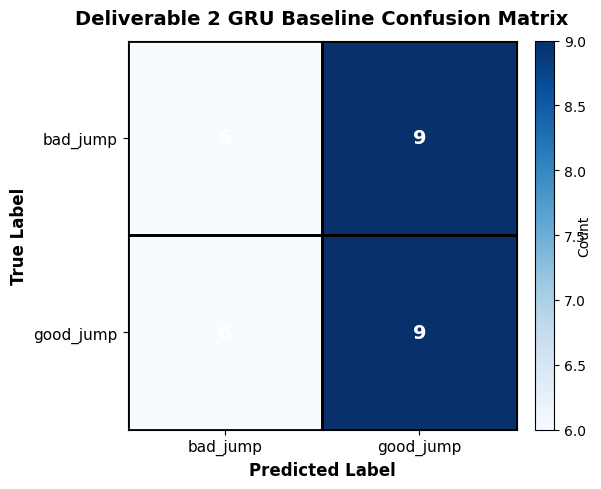

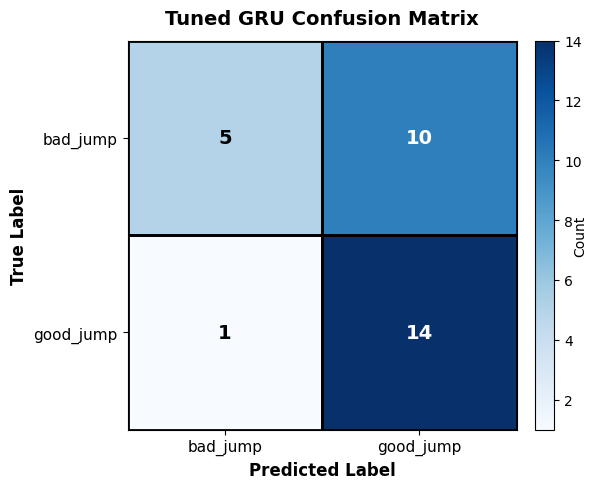

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# ------------------------------------------------------------
# Aggregate confusion matrices from Deliverable 3 report
# Rows = true labels, Columns = predicted labels
# Label order: [bad_jump, good_jump]
# ------------------------------------------------------------
cm_d2 = np.array([
    [6, 9],
    [6, 9]
])

cm_d3 = np.array([
    [5, 10],
    [1, 14]
])

class_names = ["bad_jump", "good_jump"]

def plot_confusion_matrix_boxed(
    cm,
    class_names,
    title="Confusion Matrix",
    cmap="Blues",
    figsize=(6, 5),
    save_path=None
):
    """
    Plot a clean confusion matrix with colored boxes and labels.

    Parameters
    ----------
    cm : np.ndarray
        2x2 confusion matrix.
    class_names : list[str]
        Class labels in row/column order.
    title : str
        Title of the plot.
    cmap : str
        Matplotlib colormap name.
    figsize : tuple
        Figure size.
    save_path : str or None
        If provided, save figure to this path.
    """
    cm = np.asarray(cm)
    n_rows, n_cols = cm.shape

    fig, ax = plt.subplots(figsize=figsize)

    # Heatmap background
    im = ax.imshow(cm, cmap=cmap)

    # Draw cell borders explicitly so each box is clear
    for i in range(n_rows):
        for j in range(n_cols):
            rect = Rectangle(
                (j - 0.5, i - 0.5),
                1,
                1,
                fill=False,
                edgecolor="black",
                linewidth=2
            )
            ax.add_patch(rect)

            # Choose text color for contrast
            threshold = cm.max() / 2.0
            text_color = "white" if cm[i, j] > threshold else "black"

            ax.text(
                j,
                i,
                f"{cm[i, j]}",
                ha="center",
                va="center",
                fontsize=14,
                fontweight="bold",
                color=text_color
            )

    # Axis labels and ticks
    ax.set_xticks(np.arange(n_cols))
    ax.set_yticks(np.arange(n_rows))
    ax.set_xticklabels(class_names, rotation=0, fontsize=11)
    ax.set_yticklabels(class_names, fontsize=11)

    ax.set_xlabel("Predicted Label", fontsize=12, fontweight="bold")
    ax.set_ylabel("True Label", fontsize=12, fontweight="bold")
    ax.set_title(title, fontsize=14, fontweight="bold", pad=12)

    # Add colorbar
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.set_ylabel("Count", rotation=90, va="bottom")

    # Clean layout
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


# ------------------------------------------------------------
# Plot each matrix separately
# ------------------------------------------------------------
plot_confusion_matrix_boxed(
    cm_d2,
    class_names,
    title="Deliverable 2 GRU Baseline Confusion Matrix",
    save_path="cm_gru_d2.png"
)

plot_confusion_matrix_boxed(
    cm_d3,
    class_names,
    title="Tuned GRU Confusion Matrix",
    save_path="cm_gru_d3.png"
)